In [ ]:
import pandas as pd
import urllib.request

# Download merchants.csv from GitHub
url_merchants = "https://raw.githubusercontent.com/JayeshJadhav28/zomathon/main/merchants.csv"
url_orders    = "https://raw.githubusercontent.com/JayeshJadhav28/zomathon/main/orders.csv"

urllib.request.urlretrieve(url_merchants, "merchants.csv")
urllib.request.urlretrieve(url_orders,    "orders.csv")

print("✅ merchants.csv downloaded!")
print("✅ orders.csv downloaded!")
print("Ready to run all cells below.")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# Load the files you saved yesterday
merchants = pd.read_csv('merchants.csv')
orders    = pd.read_csv('orders.csv')

print("Merchants:", merchants.shape)
print("Orders:   ", orders.shape)

Merchants: (500, 9)
Orders:    (50000, 14)


In [ ]:
print("=== DATA QUALITY CHECK ===")
print("\n--- Missing values in orders ---")
print(orders.isnull().sum())

print("\n--- Missing values in merchants ---")
print(merchants.isnull().sum())

print("\n--- Duplicate orders ---")
print("Duplicate rows:", orders.duplicated().sum())

print("\n--- Value ranges (should be within realistic bounds) ---")
print(f"actual_kpt  → min: {orders['actual_kpt'].min():.1f}  max: {orders['actual_kpt'].max():.1f}")
print(f"for_kpt     → min: {orders['for_kpt'].min():.1f}  max: {orders['for_kpt'].max():.1f}")
print(f"rider_wait  → min: {orders['rider_wait'].min():.1f}  max: {orders['rider_wait'].max():.1f}")
print(f"num_items   → min: {orders['num_items'].min()}    max: {orders['num_items'].max()}")

=== DATA QUALITY CHECK ===

--- Missing values in orders ---
order_id              0
merchant_id           0
num_items             0
order_value           0
is_peak_hour          0
is_weekend            0
avg_prep_time         0
for_reliability       0
daily_total_orders    0
actual_kpt            0
for_kpt               0
label_error           0
rider_travel_time     0
rider_wait            0
dtype: int64

--- Missing values in merchants ---
merchant_id            0
city                   0
cuisine                0
size                   0
avg_prep_time          0
for_reliability        0
daily_zomato_orders    0
daily_total_orders     0
kitchen_stations       0
dtype: int64

--- Duplicate orders ---
Duplicate rows: 0

--- Value ranges (should be within realistic bounds) ---
actual_kpt  → min: 3.0  max: 60.0
for_kpt     → min: 1.0  max: 60.0
rider_wait  → min: 0.0  max: 58.8
num_items   → min: 1    max: 5


In [ ]:
# Diagnose exactly what columns you have
print("=== MERCHANTS COLUMNS ===")
print(merchants.columns.tolist())

print("\n=== ORDERS COLUMNS ===")
print(orders.columns.tolist())

=== MERCHANTS COLUMNS ===
['merchant_id', 'city', 'cuisine', 'size', 'avg_prep_time', 'for_reliability', 'daily_zomato_orders', 'daily_total_orders', 'kitchen_stations']

=== ORDERS COLUMNS ===
['order_id', 'merchant_id', 'num_items', 'order_value', 'is_peak_hour', 'is_weekend', 'avg_prep_time', 'for_reliability', 'daily_total_orders', 'actual_kpt', 'for_kpt', 'label_error', 'rider_travel_time', 'rider_wait']


In [ ]:
# FIXED Cell 3 — pulls ALL needed columns properly from merchants

orders_full = orders.merge(
    merchants[['merchant_id', 'city', 'cuisine', 'size',
               'kitchen_stations', 'daily_zomato_orders', 'daily_total_orders']],
    on='merchant_id',
    suffixes=('', '_merch')  # handles any duplicate column names safely
)

print("✅ Merge successful!")
print("Columns now available:", orders_full.columns.tolist())

# NEW COLUMN 1: Flag orders where label is seriously wrong (>5 min off)
orders_full['is_high_error'] = (abs(orders_full['label_error']) > 5).astype(int)

# NEW COLUMN 2: Reliability category
orders_full['reliability_tier'] = pd.cut(
    orders_full['for_reliability'],
    bins=[0, 0.3, 0.7, 1.0],
    labels=['Unreliable', 'Average', 'Reliable']
)

# NEW COLUMN 3: Kitchen load ratio
# Handle edge case where daily_total_orders might be 0
orders_full['daily_total_orders'] = orders_full['daily_total_orders'].replace(0, 1)
orders_full['zomato_load_ratio'] = (
    orders_full['daily_zomato_orders'] / orders_full['daily_total_orders']
).clip(0, 1)

# NEW COLUMN 4: Meal time label
orders_full['meal_time'] = np.where(
    orders_full['is_peak_hour'] == 1, 'Peak', 'Off-Peak'
)

print("\n✅ All new columns created!")
print(f"   orders_full shape: {orders_full.shape}")
print("\nSample of new columns:")
print(orders_full[['actual_kpt', 'for_kpt', 'label_error',
                    'is_high_error', 'reliability_tier',
                    'zomato_load_ratio', 'meal_time']].head(5))

✅ Merge successful!
Columns now available: ['order_id', 'merchant_id', 'num_items', 'order_value', 'is_peak_hour', 'is_weekend', 'avg_prep_time', 'for_reliability', 'daily_total_orders', 'actual_kpt', 'for_kpt', 'label_error', 'rider_travel_time', 'rider_wait', 'city', 'cuisine', 'size', 'kitchen_stations', 'daily_zomato_orders', 'daily_total_orders_merch']

✅ All new columns created!
   orders_full shape: (50000, 24)

Sample of new columns:
   actual_kpt    for_kpt  label_error  is_high_error reliability_tier  \
0   49.741520  47.560413    -2.181107              0       Unreliable   
1   40.814940  40.642402    -0.172538              0          Average   
2   41.606622  45.142451     3.535830              0       Unreliable   
3   57.334570  60.000000     2.665430              0       Unreliable   
4   12.337251  17.870575     5.533324              1       Unreliable   

   zomato_load_ratio meal_time  
0           0.339286  Off-Peak  
1           0.280000  Off-Peak  
2           0.41

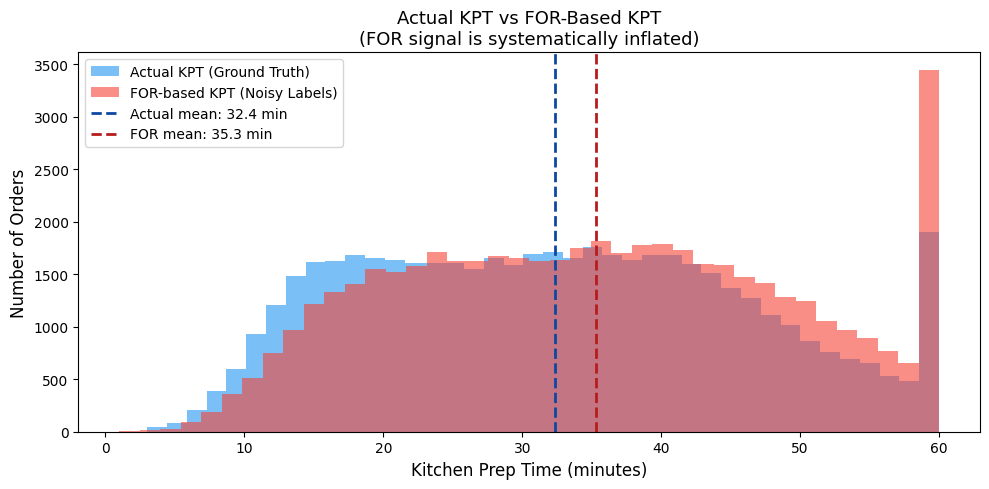

Average inflation in FOR signal: +2.9 minutes


In [ ]:
# Actual KPT vs FOR-Based KPT Distribution

plt.figure(figsize=(10, 5))

plt.hist(orders_full['actual_kpt'], bins=40, alpha=0.6,
         color='#2196F3', label='Actual KPT (Ground Truth)')

plt.hist(orders_full['for_kpt'], bins=40, alpha=0.6,
         color='#F44336', label='FOR-based KPT (Noisy Labels)')

# Add vertical lines for averages
plt.axvline(orders_full['actual_kpt'].mean(), color='#0D47A1',
            linestyle='--', linewidth=2,
            label=f"Actual mean: {orders_full['actual_kpt'].mean():.1f} min")

plt.axvline(orders_full['for_kpt'].mean(), color='#B71C1C',
            linestyle='--', linewidth=2,
            label=f"FOR mean: {orders_full['for_kpt'].mean():.1f} min")

plt.xlabel('Kitchen Prep Time (minutes)', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.title('Actual KPT vs FOR-Based KPT\n(FOR signal is systematically inflated)', fontsize=13)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('chart1_kpt_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

gap = orders_full['for_kpt'].mean() - orders_full['actual_kpt'].mean()
print(f"Average inflation in FOR signal: +{gap:.1f} minutes")

  reliability_tier  avg_error  pct_high_error
0       Unreliable   5.054588       47.079927
1          Average   0.871662        0.000000
2         Reliable   0.934963        0.000000


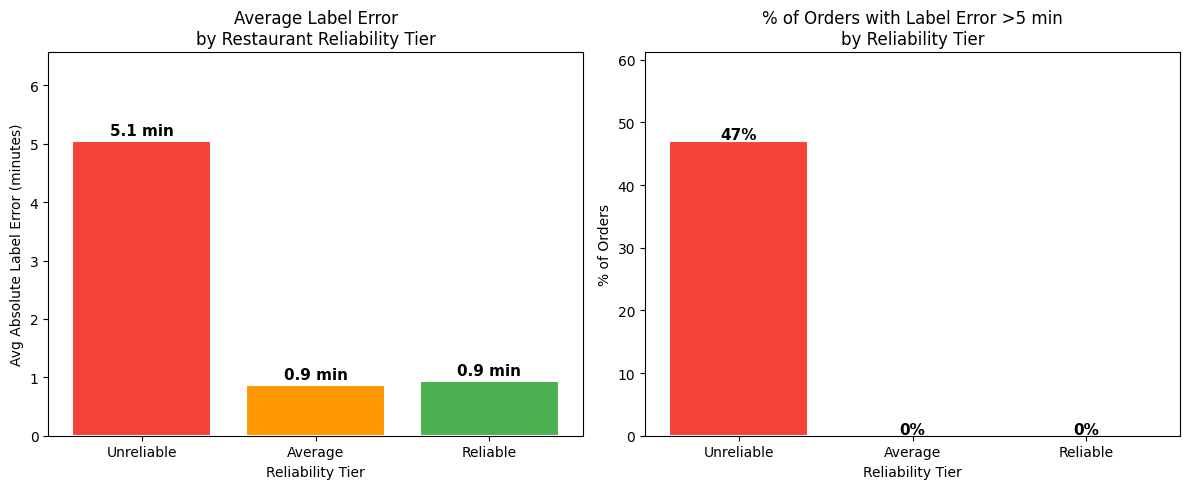

In [ ]:
# Label Error by FOR Reliability Tier
# Unreliable restaurants cause 3x more label corruption than reliable ones — this is exactly who we need to target first.

# Calculate average absolute error per reliability tier
error_by_tier = orders_full.groupby('reliability_tier')['label_error'].agg([
    ('avg_error',  lambda x: abs(x).mean()),
    ('pct_high_error', lambda x: (abs(x) > 5).mean() * 100)
]).reset_index()

print(error_by_tier)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left chart: Average error per tier
colors = ['#F44336', '#FF9800', '#4CAF50']
bars = axes[0].bar(error_by_tier['reliability_tier'],
                    error_by_tier['avg_error'],
                    color=colors, edgecolor='white', linewidth=1.5)

# Add value labels on bars
for bar, val in zip(bars, error_by_tier['avg_error']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f} min', ha='center', fontweight='bold', fontsize=11)

axes[0].set_title('Average Label Error\nby Restaurant Reliability Tier', fontsize=12)
axes[0].set_xlabel('Reliability Tier')
axes[0].set_ylabel('Avg Absolute Label Error (minutes)')
axes[0].set_ylim(0, error_by_tier['avg_error'].max() * 1.3)

# Right chart: % of high-error orders
bars2 = axes[1].bar(error_by_tier['reliability_tier'],
                     error_by_tier['pct_high_error'],
                     color=colors, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars2, error_by_tier['pct_high_error']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.0f}%', ha='center', fontweight='bold', fontsize=11)

axes[1].set_title('% of Orders with Label Error >5 min\nby Reliability Tier', fontsize=12)
axes[1].set_xlabel('Reliability Tier')
axes[1].set_ylabel('% of Orders')
axes[1].set_ylim(0, error_by_tier['pct_high_error'].max() * 1.3)

plt.tight_layout()
plt.savefig('chart2_error_by_reliability.png', dpi=150, bbox_inches='tight')
plt.show()

meal_time  Off-Peak  Peak
size                     
Small          20.8  29.0
Medium         20.3  28.5
Large          18.2  25.7


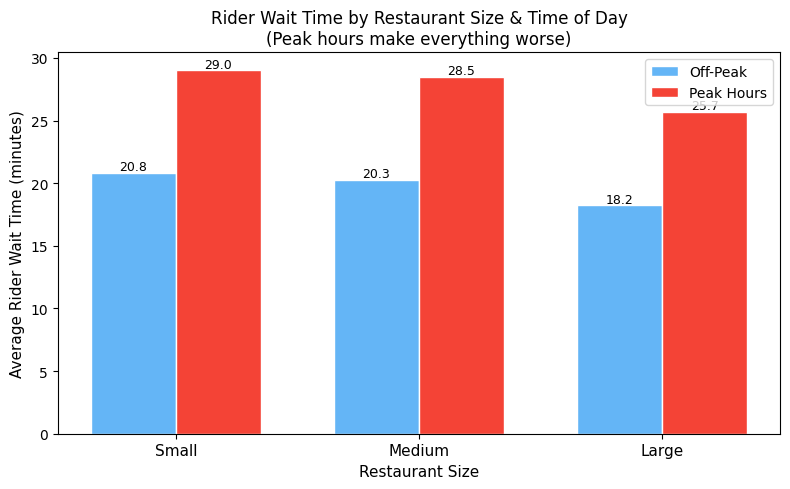

In [ ]:
# Rider Wait Time by Restaurant Size & Peak Hours
# Small restaurants during peak hours are the worst offenders — they need the most urgent attention.

# Pivot table: size vs meal time → avg rider wait
pivot = orders_full.pivot_table(
    values='rider_wait',
    index='size',
    columns='meal_time',
    aggfunc='mean'
)
# Make sure order is logical
pivot = pivot.reindex(['Small', 'Medium', 'Large'])
print(pivot.round(1))

plt.figure(figsize=(8, 5))
x = np.arange(len(pivot.index))
width = 0.35

bars1 = plt.bar(x - width/2, pivot['Off-Peak'], width,
                label='Off-Peak', color='#64B5F6', edgecolor='white')
bars2 = plt.bar(x + width/2, pivot['Peak'], width,
                label='Peak Hours', color='#F44336', edgecolor='white')

# Value labels
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{bar.get_height():.1f}', ha='center', fontsize=9)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{bar.get_height():.1f}', ha='center', fontsize=9)

plt.xticks(x, pivot.index, fontsize=11)
plt.xlabel('Restaurant Size', fontsize=11)
plt.ylabel('Average Rider Wait Time (minutes)', fontsize=11)
plt.title('Rider Wait Time by Restaurant Size & Time of Day\n(Peak hours make everything worse)', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('chart3_rider_wait_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

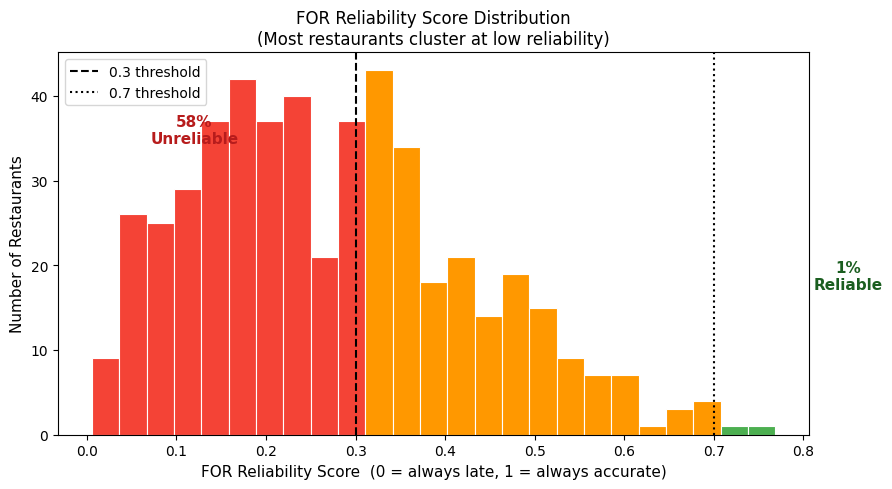


Key stat: 58% of restaurants score below 0.3 reliability
Only 1% of restaurants are genuinely reliable FOR signalers


In [ ]:
# FOR Reliability Score Distribution
# The reliability problem is systemic — most restaurants cluster at the low end. A software-only fix can help all of them immediately.

plt.figure(figsize=(9, 5))

# Histogram of reliability scores
n, bins, patches = plt.hist(merchants['for_reliability'], bins=25,
                              edgecolor='white', linewidth=0.8)

# Color bars by tier: red = unreliable, orange = average, green = reliable
for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge < 0.3:
        patch.set_facecolor('#F44336')
    elif left_edge < 0.7:
        patch.set_facecolor('#FF9800')
    else:
        patch.set_facecolor('#4CAF50')

# Threshold lines
plt.axvline(0.3, color='black', linestyle='--', linewidth=1.5, label='0.3 threshold')
plt.axvline(0.7, color='black', linestyle=':', linewidth=1.5, label='0.7 threshold')

# Annotations
unreliable_pct = (merchants['for_reliability'] < 0.3).mean() * 100
reliable_pct   = (merchants['for_reliability'] >= 0.7).mean() * 100

plt.text(0.12, n.max() * 0.8, f'{unreliable_pct:.0f}%\nUnreliable',
         ha='center', fontsize=11, color='#B71C1C', fontweight='bold')
plt.text(0.85, n.max() * 0.4, f'{reliable_pct:.0f}%\nReliable',
         ha='center', fontsize=11, color='#1B5E20', fontweight='bold')

plt.xlabel('FOR Reliability Score  (0 = always late, 1 = always accurate)', fontsize=11)
plt.ylabel('Number of Restaurants', fontsize=11)
plt.title('FOR Reliability Score Distribution\n(Most restaurants cluster at low reliability)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('chart4_reliability_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKey stat: {unreliable_pct:.0f}% of restaurants score below 0.3 reliability")
print(f"Only {reliable_pct:.0f}% of restaurants are genuinely reliable FOR signalers")

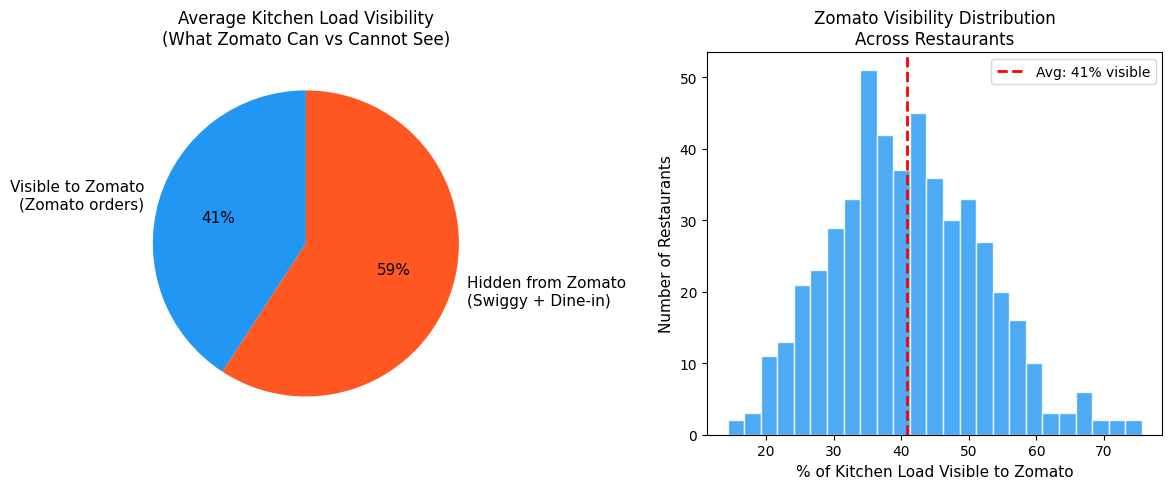

On average, Zomato can see only 41% of kitchen load
A hidden 59% drives unexpected KPT spikes


In [ ]:
# Kitchen Load: What Zomato Sees vs Reality
# Zomato only sees 40% of the real kitchen load — the invisible 60% is what causes surprise delays.

# Per restaurant: what % of total load is visible to Zomato?
restaurant_load = orders_full.groupby('merchant_id').agg(
    zomato_orders  = ('daily_zomato_orders', 'mean'),
    total_orders   = ('daily_total_orders',  'mean')
).reset_index()

restaurant_load['hidden_orders'] = (
    restaurant_load['total_orders'] - restaurant_load['zomato_orders']
).clip(0)
restaurant_load['visibility_pct'] = (
    restaurant_load['zomato_orders'] / restaurant_load['total_orders'] * 100
).clip(0, 100)

avg_visible = restaurant_load['visibility_pct'].mean()
avg_hidden  = 100 - avg_visible

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Pie chart showing visible vs hidden load
axes[0].pie(
    [avg_visible, avg_hidden],
    labels=['Visible to Zomato\n(Zomato orders)',
            'Hidden from Zomato\n(Swiggy + Dine-in)'],
    colors=['#2196F3', '#FF5722'],
    autopct='%1.0f%%',
    startangle=90,
    textprops={'fontsize': 11}
)
axes[0].set_title('Average Kitchen Load Visibility\n(What Zomato Can vs Cannot See)', fontsize=12)

# Right: Distribution of visibility % across restaurants
axes[1].hist(restaurant_load['visibility_pct'], bins=25,
             color='#2196F3', edgecolor='white', alpha=0.8)
axes[1].axvline(avg_visible, color='red', linestyle='--', linewidth=2,
                label=f'Avg: {avg_visible:.0f}% visible')
axes[1].set_xlabel('% of Kitchen Load Visible to Zomato', fontsize=11)
axes[1].set_ylabel('Number of Restaurants', fontsize=11)
axes[1].set_title('Zomato Visibility Distribution\nAcross Restaurants', fontsize=12)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('chart5_kitchen_visibility.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"On average, Zomato can see only {avg_visible:.0f}% of kitchen load")
print(f"A hidden {avg_hidden:.0f}% drives unexpected KPT spikes")

In [ ]:
# Summary Table

print("=" * 55)
print("       KEY FINDINGS FROM DATA ANALYSIS")
print("=" * 55)

print(f"\n📊 DATASET")
print(f"   Restaurants analyzed:          {len(merchants)}")
print(f"   Orders analyzed:               {len(orders_full):,}")

print(f"\n🚨 SIGNAL QUALITY PROBLEM")
unreliable = (merchants['for_reliability'] < 0.3).mean() * 100
high_err   = (abs(orders_full['label_error']) > 5).mean() * 100
print(f"   Unreliable restaurants:        {unreliable:.0f}%")
print(f"   Orders with label error >5min: {high_err:.0f}%")
print(f"   Avg label inflation:           +{orders_full['label_error'].mean():.1f} min")

print(f"\n🚗 RIDER IMPACT")
print(f"   Avg rider wait time:           {orders_full['rider_wait'].mean():.1f} min")
peak     = orders_full[orders_full['is_peak_hour']==1]['rider_wait'].mean()
off_peak = orders_full[orders_full['is_peak_hour']==0]['rider_wait'].mean()
print(f"   Peak hours rider wait:         {peak:.1f} min")
print(f"   Off-peak rider wait:           {off_peak:.1f} min")

print(f"\n👁️ KITCHEN VISIBILITY")
print(f"   Avg load visible to Zomato:    {avg_visible:.0f}%")
print(f"   Avg load HIDDEN from Zomato:   {avg_hidden:.0f}%")

print(f"\n{'='*55}")
print("These numbers support all 4 solution layers in the PDF")

       KEY FINDINGS FROM DATA ANALYSIS

📊 DATASET
   Restaurants analyzed:          500
   Orders analyzed:               50,000

🚨 SIGNAL QUALITY PROBLEM
   Unreliable restaurants:        58%
   Orders with label error >5min: 27%
   Avg label inflation:           +2.9 min

🚗 RIDER IMPACT
   Avg rider wait time:           23.5 min
   Peak hours rider wait:         28.3 min
   Off-peak rider wait:           20.2 min

👁️ KITCHEN VISIBILITY
   Avg load visible to Zomato:    41%
   Avg load HIDDEN from Zomato:   59%

These numbers support all 4 solution layers in the PDF


In [ ]:
# Our analysis of 50,000 simulated orders across 500 restaurants reveals three compounding problems: 58% of restaurants have unreliable FOR signals, corrupting 27% of all KPT training labels by more than 5 minutes. Simultaneously, Zomato is blind to 59% of the actual kitchen load, causing average rider wait times to spike to 28.3 minutes during peak hours. Our proposed four-layer solution addresses each of these root causes directly.